In [1]:
# 导入相关库
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 设置中文字体显示
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [3]:
# 1. 获取数据（标普500和上证指数）
symbols = ['^GSPC', '000001.SS']  # 标普500和上证指数
data = yf.download(symbols,period="max")['Close']
data.head(),data.tail()

/var/folders/2_/cdsnq6qs41752yj0rh6g0npr0000gn/T/ipykernel_21999/1843291437.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols,period="max")['Close']
[*********************100%***********************]  2 of 2 completed


(Ticker      000001.SS      ^GSPC
 Date                            
 1927-12-30        NaN  17.660000
 1928-01-03        NaN  17.760000
 1928-01-04        NaN  17.719999
 1928-01-05        NaN  17.549999
 1928-01-06        NaN  17.660000,
 Ticker        000001.SS        ^GSPC
 Date                                
 2025-09-15  3860.503906  6615.279785
 2025-09-16  3861.864990  6606.759766
 2025-09-17  3876.341064  6600.350098
 2025-09-18  3831.656006  6631.959961
 2025-09-19  3820.089111  6664.359863)

In [4]:
# 2. 保存数据，便于后续使用
data.to_csv('close_SP_SS.csv')
data = pd.read_csv('close_SP_SS.csv', index_col=0, parse_dates=True)
data.head(),data.tail()

(            000001.SS      ^GSPC
 Date                            
 1927-12-30        NaN  17.660000
 1928-01-03        NaN  17.760000
 1928-01-04        NaN  17.719999
 1928-01-05        NaN  17.549999
 1928-01-06        NaN  17.660000,
               000001.SS        ^GSPC
 Date                                
 2025-09-15  3860.503906  6615.279785
 2025-09-16  3861.864990  6606.759766
 2025-09-17  3876.341064  6600.350098
 2025-09-18  3831.656006  6631.959961
 2025-09-19  3820.089111  6664.359863)

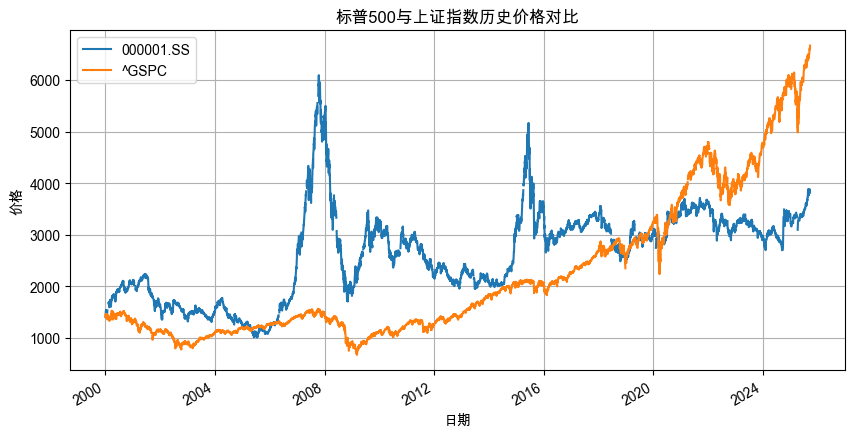

In [6]:
# 3. 可视化价格曲线
data['2000':].plot(title="标普500与上证指数历史价格对比", xlabel="日期", ylabel="价格", grid=True, figsize=[10,5])
plt.legend([symbols[1], symbols[0]])

In [7]:
# 4. 定义买入卖出点（选择特定的一点）
buy_date = '2020-09-02'  # 假设买入点
sell_date = '2025-09-02'  # 假设卖出点

buy_price_sp500 = data.loc[buy_date, '^GSPC']
sell_price_sp500 = data.loc[sell_date, '^GSPC']

buy_price_sh = data.loc[buy_date, '000001.SS']
sell_price_sh = data.loc[sell_date, '000001.SS']

# 打印买入、卖出时间和价格
print(f"买入点: {buy_date}, 标普500价格: {buy_price_sp500}, 上证指数价格: {buy_price_sh}")
print(f"卖出点: {sell_date}, 标普500价格: {sell_price_sp500}, 上证指数价格: {sell_price_sh}")

买入点: 2020-09-02, 标普500价格: 3580.840087890625, 上证指数价格: 3404.802001953125
卖出点: 2025-09-02, 标普500价格: 6415.5400390625, 上证指数价格: 3858.133056640625


In [8]:
# 5. 计算累计收益率：（期末价格 - 期初价格） / 期初价格
cumulative_profit_sp500 = (sell_price_sp500 - buy_price_sp500) / buy_price_sp500
cumulative_profit_sh = (sell_price_sh - buy_price_sh) / buy_price_sh
cumulative_profit_sp500, cumulative_profit_sh

(0.7916298638294454, 0.13314461587706183)

In [10]:
# 6. 计算年化收益率：（(1 + 累计收益率)**(1/T) - 1, T表示投资年数，252->T = days/252
days_held = (pd.to_datetime(sell_date) - pd.to_datetime(buy_date)).days
annual_profit_sp500 = (1+cumulative_profit_sp500)**(252/days_held) - 1
annual_profit_sh = (1+cumulative_profit_sh)**(252/days_held) - 1

annual_profit_sp500,annual_profit_sh

(0.08380195157442394, 0.017400000740261046)

In [11]:
# 7. 计算超额收益率：我们想看看假设投入标普比投入上证能多赚多少？
excess_return_sp500 = cumulative_profit_sp500 - cumulative_profit_sh
excess_return_sp500

0.6584852479523836